# Gesamtanalyse – ARIMA-Modell Luftdruck Würzburg

**Datenquelle:** `data/cleaned/wuerzburg_klima_tagesdaten_05705_clean_2.csv` – Spalte `PM`
**Ausgabe:** `Plots/` (7 Abbildungen)

**Komplettes ARIMA-Modell** – von den bereinigten Tagesdaten bis zur 10-Tage-Prognose
inklusive Train/Test-Evaluation und 5-Fold-Cross-Validation.

Box-Jenkins-Schritte: Stationaritätstests → Transformation → ACF/PACF →
Modellselektion → Residuendiagnose → t-Statistiken → Prognose → Evaluation.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
import itertools

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
from pathlib import Path

def _repo_root():
    p = Path().resolve()
    for folder in [p, *p.parents]:
        if (folder / ".git").is_dir():
            return folder
    return p

ROOT     = _repo_root()
CSV_PFAD = ROOT / "data" / "cleaned" / "wuerzburg_klima_tagesdaten_05705_clean_2.csv"
PLOTORDNER = "Plots"
os.makedirs(PLOTORDNER, exist_ok=True)

## 0. DATEN LADEN UND VORVERARBEITEN

In [ ]:
# Daten aus bereinigter CSV laden
df_clean = pd.read_csv(CSV_PFAD, parse_dates=["MESS_DATUM"], index_col="MESS_DATUM")
df_clean.index.freq = "D"
ts       = df_clean["PM"].rename("PP_TER")   # Luftdruck [hPa]

# Monatsmittel fuer Uebersichtsplot
ts_daily   = ts.copy()
ts_monthly = ts.resample("MS").mean()

print(f"Datensatz: {ts.index[0].date()} bis {ts.index[-1].date()}")
print(f"Tageswerte: {len(ts):,}  |  Monatswerte: {len(ts_monthly):,}")
print(f"Mittelwert: {ts.mean():.2f} hPa  |  Std: {ts.std():.2f} hPa")

## 1. ROHDATEN VISUALISIERUNG

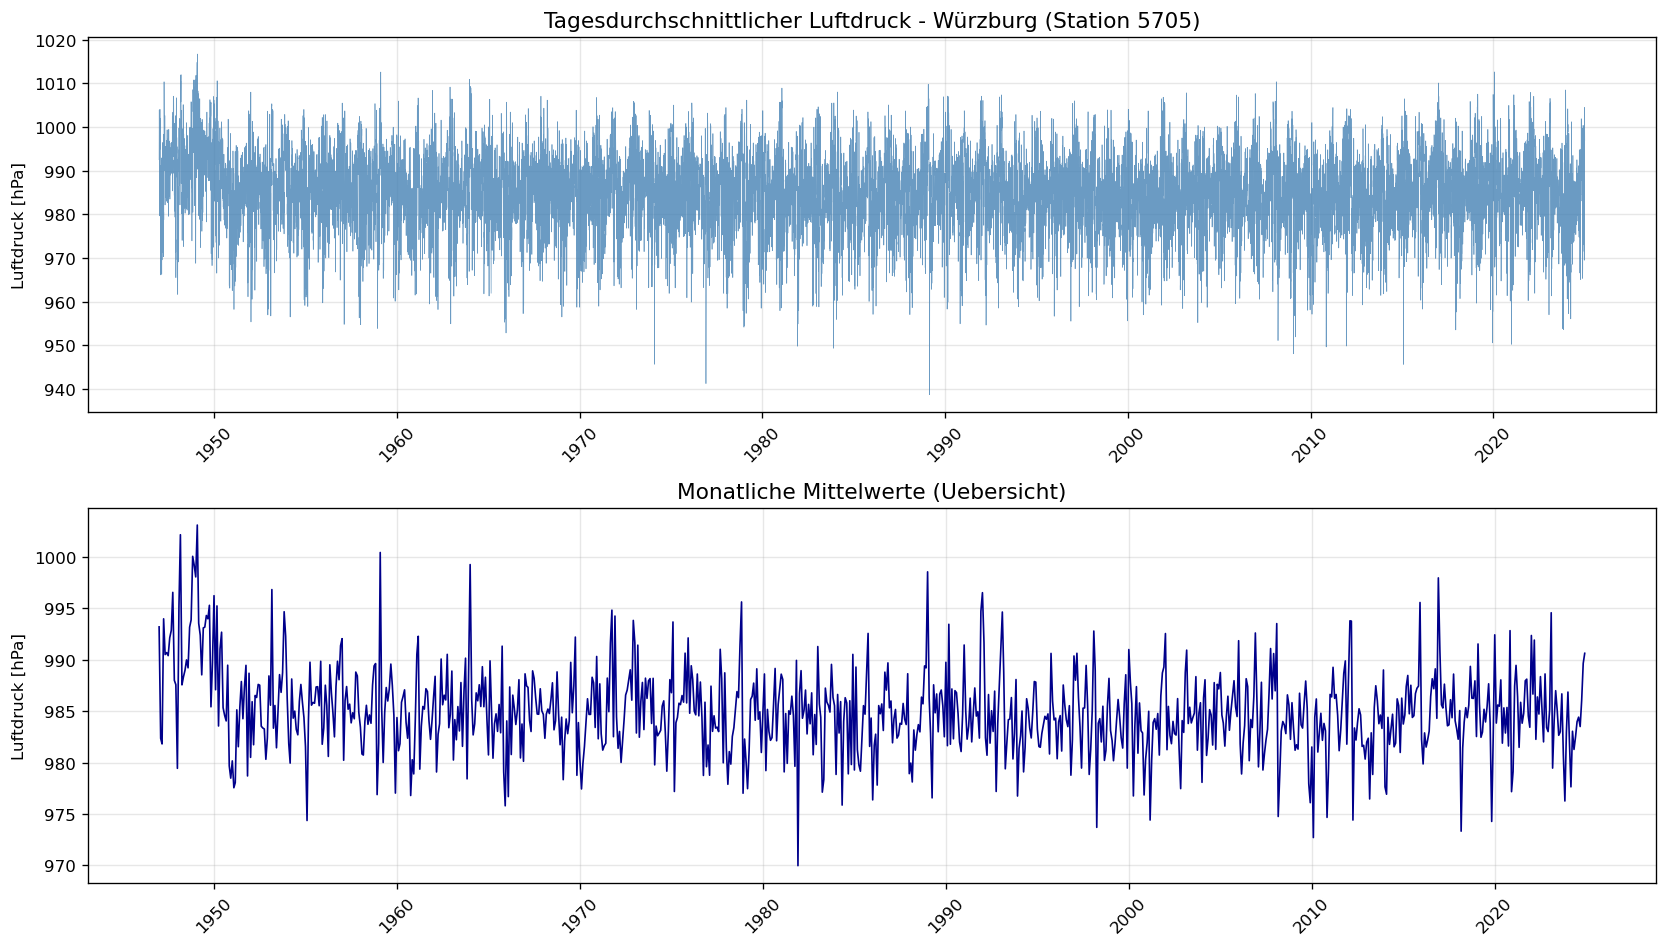


[Abbildung 1 gespeichert: 01_rohdaten.png]


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
axes[0].plot(ts_daily.index, ts_daily.values, lw=0.4, color="steelblue", alpha=0.8)
axes[0].set_title(
    "Tagesdurchschnittlicher Luftdruck - Würzburg (Station 5705)", fontsize=13
)
axes[0].set_ylabel("Luftdruck [hPa]")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].xaxis.set_major_locator(mdates.YearLocator(10))

axes[1].plot(ts_monthly.index, ts_monthly.values, lw=1.0, color="darkblue")
axes[1].set_title(
    "Monatliche Mittelwerte (Uebersicht)", fontsize=13
)
axes[1].set_ylabel("Luftdruck [hPa]")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(10))

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "01_rohdaten.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 1 gespeichert: 01_rohdaten.png]")

## 2. STATIONARITAETSTESTS (SCHRITT 1: INTEGRATIONSORDNUNG)

In [4]:
print("\n" + "=" * 65)
print("SCHRITT 1: INTEGRATIONSORDNUNG - STATIONARITAETSTESTS")
print("=" * 65)


def adf_test(serie, bezeichnung=""):
    """Augmented Dickey-Fuller Test mit automatischer Lag-Auswahl (AIC)."""
    result = adfuller(serie.dropna(), autolag="AIC")
    print(f"\n  ADF-Test: {bezeichnung}")
    print(f"    Teststatistik : {result[0]:.4f}")
    print(f"    p-Wert        : {result[1]:.4f}")
    print(f"    Lags verwendet: {result[2]}")
    print(
        f"    Krit. Werte   : 1%={result[4]['1%']:.3f}, "
        f"5%={result[4]['5%']:.3f}, 10%={result[4]['10%']:.3f}"
    )
    entscheidung = "STATIONAER" if result[1] < 0.05 else "NICHT STATIONAER"
    print(f"    => Entscheidung (5% Niveau): {entscheidung}")
    return result[1]


def kpss_test(serie, bezeichnung=""):
    """KPSS-Test (H0: Stationaritaet)."""
    result = kpss(serie.dropna(), regression="c", nlags="auto")
    print(f"\n  KPSS-Test: {bezeichnung}")
    print(f"    Teststatistik : {result[0]:.4f}")
    print(f"    p-Wert        : {result[1]:.4f}")
    print(f"    Krit. Werte   : {result[3]}")
    entscheidung = "NICHT STATIONAER" if result[1] < 0.05 else "STATIONAER"
    print(f"    => Entscheidung (5% Niveau): {entscheidung}")
    return result[1]


# Niveau
print("\n--- Niveau der Zeitreihe ---")
p_adf_niveau = adf_test(ts, "Taeglicher Luftdruck (Niveau)")
p_kpss_niveau = kpss_test(ts, "Taeglicher Luftdruck (Niveau)")

# Erste Differenz
ts_diff1 = ts.diff().dropna()
print("\n--- Erste Differenz ---")
p_adf_d1 = adf_test(ts_diff1, "Erste Differenz (d=1)")
p_kpss_d1 = kpss_test(ts_diff1, "Erste Differenz (d=1)")

# Integrationsordnung bestimmen
if p_adf_niveau < 0.05 and p_kpss_niveau >= 0.05:
    d = 0
    print("\n  => Zeitreihe ist im NIVEAU stationaer => d = 0")
elif p_adf_d1 < 0.05 or p_kpss_d1 >= 0.05:
    d = 1
    print("\n  => Zeitreihe wird nach ERSTER DIFFERENZIERUNG stationaer => d = 1")
else:
    d = 1
    print("\n  => d = 1 (konservative Wahl bei gemischten Testergebnissen)")

print(f"\n  Gewaehlte Integrationsordnung: d = {d}")


SCHRITT 1: INTEGRATIONSORDNUNG - STATIONARITAETSTESTS

--- Niveau der Zeitreihe ---

  ADF-Test: Taeglicher Luftdruck (Niveau)
    Teststatistik : -18.2370
    p-Wert        : 0.0000
    Lags verwendet: 49
    Krit. Werte   : 1%=-3.431, 5%=-2.862, 10%=-2.567
    => Entscheidung (5% Niveau): STATIONAER

  KPSS-Test: Taeglicher Luftdruck (Niveau)
    Teststatistik : 2.3983
    p-Wert        : 0.0100
    Krit. Werte   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
    => Entscheidung (5% Niveau): NICHT STATIONAER

--- Erste Differenz ---


C:\Users\Susi_\AppData\Local\Temp\ipykernel_26372\240320992.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(serie.dropna(), regression="c", nlags="auto")



  ADF-Test: Erste Differenz (d=1)
    Teststatistik : -40.2433
    p-Wert        : 0.0000
    Lags verwendet: 48
    Krit. Werte   : 1%=-3.431, 5%=-2.862, 10%=-2.567
    => Entscheidung (5% Niveau): STATIONAER

  KPSS-Test: Erste Differenz (d=1)
    Teststatistik : 0.0288
    p-Wert        : 0.1000
    Krit. Werte   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
    => Entscheidung (5% Niveau): STATIONAER

  => Zeitreihe wird nach ERSTER DIFFERENZIERUNG stationaer => d = 1

  Gewaehlte Integrationsordnung: d = 1


C:\Users\Susi_\AppData\Local\Temp\ipykernel_26372\240320992.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(serie.dropna(), regression="c", nlags="auto")


## 3. TRANSFORMATION (SCHRITT 2: STATIONARITAET HERSTELLEN)


SCHRITT 2: TRANSFORMATION ZUR STATIONARITAET
  1-fache Differenzierung angewendet.
  Neue Reihe: 28489 Beobachtungen
  Mittelwert: 0.0002 hPa  |  Std: 5.3049 hPa


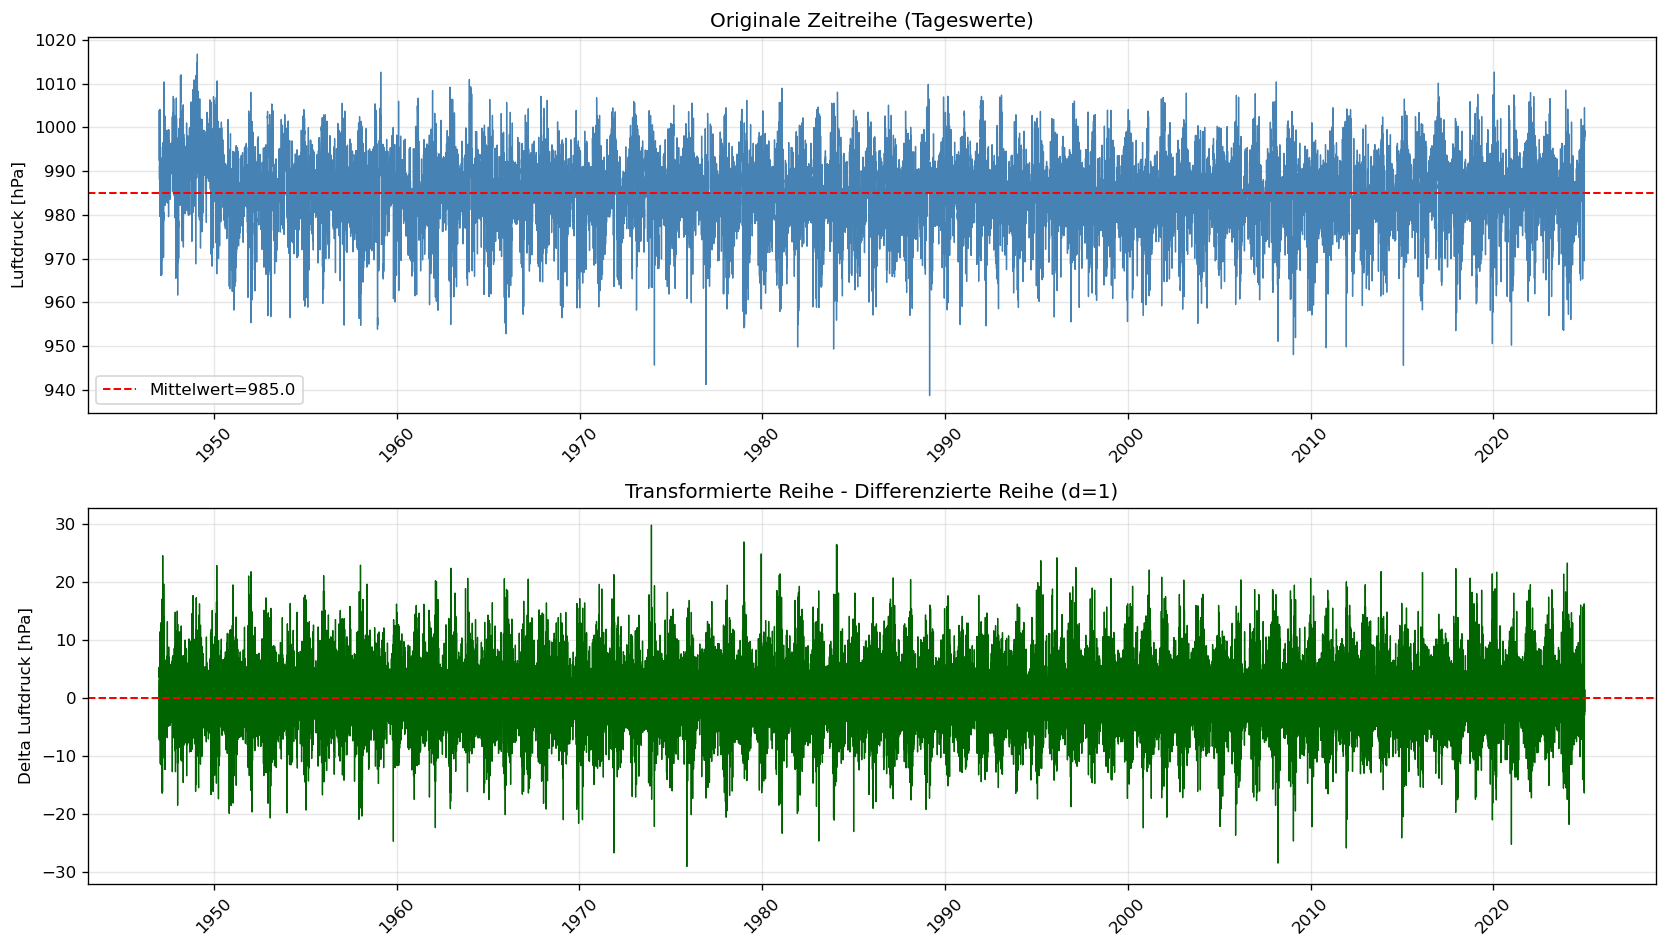


[Abbildung 2 gespeichert: 02_transformation.png]


In [5]:
print("\n" + "=" * 65)
print("SCHRITT 2: TRANSFORMATION ZUR STATIONARITAET")
print("=" * 65)

if d == 0:
    ts_stat = ts.copy()
    print("  Keine Differenzierung notwendig - Niveau wird verwendet.")
else:
    ts_stat = ts.diff(d).dropna()
    print(f"  {d}-fache Differenzierung angewendet.")
    print(f"  Neue Reihe: {len(ts_stat)} Beobachtungen")
    print(f"  Mittelwert: {ts_stat.mean():.4f} hPa  |  Std: {ts_stat.std():.4f} hPa")

# Visualisierung der Transformation
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(ts.index, ts.values, color="steelblue", lw=0.8)
axes[0].set_title("Originale Zeitreihe (Tageswerte)", fontsize=12)
axes[0].set_ylabel("Luftdruck [hPa]")
axes[0].axhline(
    ts.mean(), color="red", ls="--", lw=1.2, label=f"Mittelwert={ts.mean():.1f}"
)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts_stat.index, ts_stat.values, color="darkgreen", lw=0.8)
titel = "Differenzierte Reihe (d=1)" if d > 0 else "Niveau-Reihe (d=0)"
axes[1].set_title(f"Transformierte Reihe - {titel}", fontsize=12)
axes[1].set_ylabel("Delta Luftdruck [hPa]" if d > 0 else "Luftdruck [hPa]")
axes[1].axhline(0, color="red", ls="--", lw=1.2)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "02_transformation.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 2 gespeichert: 02_transformation.png]")

## 4. ACF UND PACF (SCHRITT 3)


SCHRITT 3: ACF UND PACF DER TRANSFORMIERTEN REIHE


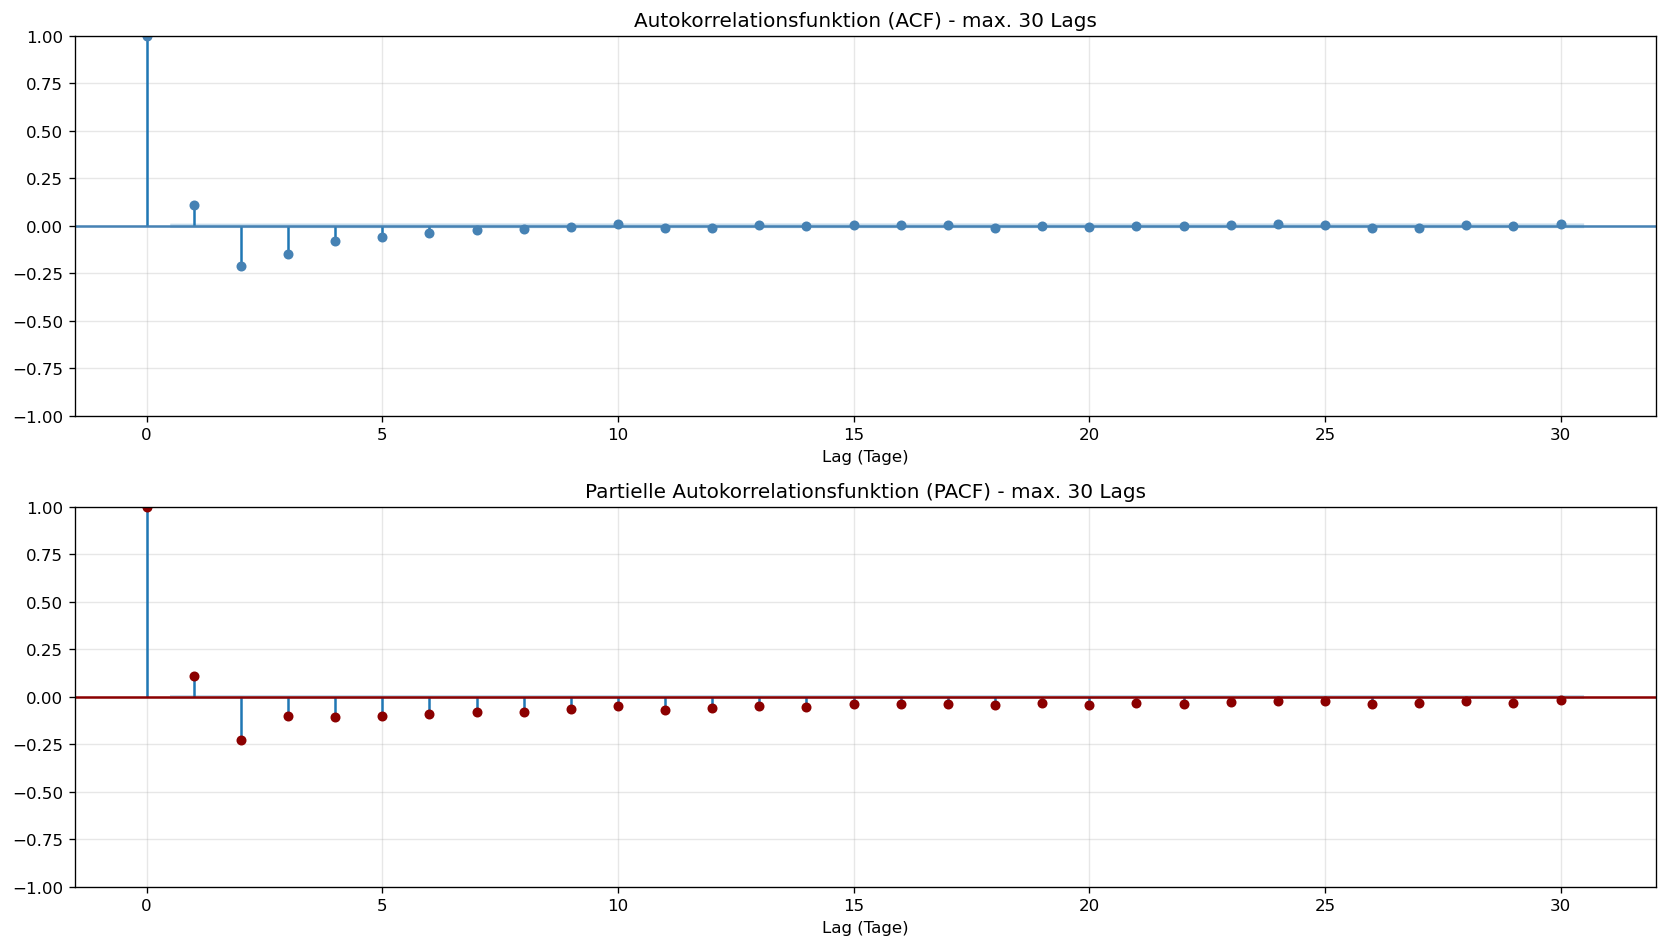


[Abbildung 3 gespeichert: 03_acf_pacf.png]

  Signifikante ACF-Lags  (5%): [1, 2, 3, 4, 5, 6, 7, 8, 11, 12]
  Signifikante PACF-Lags (5%): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

  Interpretation:
  - Abrupter Abfall der PACF nach Lag p => AR(p)-Anteil
  - Abrupter Abfall der ACF nach Lag q  => MA(q)-Anteil
  - Geometrisch abklingende ACF + PACF-Abbruch => AR-Prozess
  - Geometrisch abklingende PACF + ACF-Abbruch => MA-Prozess



In [6]:
print("\n" + "=" * 65)
print("SCHRITT 3: ACF UND PACF DER TRANSFORMIERTEN REIHE")
print("=" * 65)

max_lag = 30
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_stat, lags=max_lag, ax=axes[0], alpha=0.05, color="steelblue")
axes[0].set_title(
    f"Autokorrelationsfunktion (ACF) - max. {max_lag} Lags", fontsize=12
)
axes[0].set_xlabel("Lag (Tage)")
axes[0].grid(True, alpha=0.3)

plot_pacf(ts_stat, lags=max_lag, ax=axes[1], alpha=0.05, color="darkred", method="ywm")
axes[1].set_title(
    f"Partielle Autokorrelationsfunktion (PACF) - max. {max_lag} Lags", fontsize=12
)
axes[1].set_xlabel("Lag (Tage)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "03_acf_pacf.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 3 gespeichert: 03_acf_pacf.png]")

# Signifikante ACF/PACF-Lags ausgeben
acf_werte = acf(ts_stat, nlags=max_lag, alpha=0.05)
pacf_werte = pacf(ts_stat, nlags=max_lag, alpha=0.05, method="ywm")
acf_konf = acf_werte[1]
pacf_konf = pacf_werte[1]

sig_acf = [
    i for i in range(1, max_lag + 1)
    if abs(acf_werte[0][i]) > (acf_konf[i, 1] - acf_werte[0][i])
]
sig_pacf = [
    i for i in range(1, max_lag + 1)
    if abs(pacf_werte[0][i]) > (pacf_konf[i, 1] - pacf_werte[0][i])
]

print(f"\n  Signifikante ACF-Lags  (5%): {sig_acf[:10]}")
print(f"  Signifikante PACF-Lags (5%): {sig_pacf[:10]}")
print(
    "\n  Interpretation:\n"
    "  - Abrupter Abfall der PACF nach Lag p => AR(p)-Anteil\n"
    "  - Abrupter Abfall der ACF nach Lag q  => MA(q)-Anteil\n"
    "  - Geometrisch abklingende ACF + PACF-Abbruch => AR-Prozess\n"
    "  - Geometrisch abklingende PACF + ACF-Abbruch => MA-Prozess\n"
)

## 5. MODELLSELEKTION (SCHRITT 4)

In [9]:
print("\n" + "=" * 65)
print("SCHRITT 4: MODELLSELEKTION - ARIMA(p,d,q)")
print("=" * 65)

p_werte = range(0, 4)
q_werte = range(0, 4)
ergebnisse = []

print(f"\n  Schaetze ARIMA(p,{d},q) fuer p,q in {{0,1,2,3}} ...")

for p, q in itertools.product(p_werte, q_werte):
    if p == 0 and q == 0:
        continue
    try:
        modell = ARIMA(ts, order=(p, d, q))
        fit = modell.fit()
        ergebnisse.append({
            "p": p, "q": q,
            "AIC": round(fit.aic, 2),
            "BIC": round(fit.bic, 2),
            "LogLik": round(fit.llf, 2),
        })
    except Exception:
        pass

ergebnis_df = pd.DataFrame(ergebnisse).sort_values("AIC")
print("\n  Modellvergleich (sortiert nach AIC):")
print(ergebnis_df.to_string(index=False))

bestes_modell_info = ergebnis_df.iloc[0]
p_best = int(bestes_modell_info["p"])
q_best = int(bestes_modell_info["q"])

# Auch nach BIC bestes Modell
bestes_bic = ergebnis_df.sort_values("BIC").iloc[0]
p_bic = int(bestes_bic["p"])
q_bic = int(bestes_bic["q"])

print(f"\n  Bestes Modell nach AIC: ARIMA({p_best},{d},{q_best})  AIC={bestes_modell_info['AIC']}")
print(f"  Bestes Modell nach BIC: ARIMA({p_bic},{d},{q_bic})   BIC={bestes_bic['BIC']}")

# Wenn AIC und BIC abweichen, nehmen wir AIC
p_final, d_final, q_final = p_best, d, q_best
print(f"\n  => Gewaaehltes Modell: ARIMA({p_final},{d_final},{q_final}) [nach AIC]")


SCHRITT 4: MODELLSELEKTION - ARIMA(p,d,q)

  Schaetze ARIMA(p,1,q) fuer p,q in {0,1,2,3} ...


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  Modellvergleich (sortiert nach AIC):
 p  q       AIC       BIC    LogLik
 3  1 170982.41 171023.70 -85486.20
 3  2 170983.75 171033.29 -85485.87
 3  3 170994.14 171051.94 -85490.07
 1  2 170999.88 171032.90 -85495.94
 1  3 171001.82 171043.10 -85495.91
 2  2 171001.83 171043.11 -85495.91
 2  3 171002.63 171052.17 -85495.31
 2  1 171234.14 171267.17 -85613.07
 0  3 172771.85 172804.88 -86381.93
 3  0 173801.79 173834.82 -86896.90
 2  0 174100.29 174125.07 -87047.15
 0  2 174148.78 174173.55 -87071.39
 1  1 175004.75 175029.53 -87499.38
 0  1 175357.07 175373.58 -87676.54
 1  0 175581.95 175598.46 -87788.97

  Bestes Modell nach AIC: ARIMA(3,1,1)  AIC=170982.41
  Bestes Modell nach BIC: ARIMA(3,1,1)   BIC=171023.7

  => Gewaaehltes Modell: ARIMA(3,1,1) [nach AIC]


## 6. FINALES MODELL SCHAETZEN

In [10]:
print("\n" + "=" * 65)
print(f"SCHRITT 5 & 6: MODELLSCHAETZUNG ARIMA({p_final},{d_final},{q_final})")
print("=" * 65)

modell_final = ARIMA(ts, order=(p_final, d_final, q_final))
fit_final = modell_final.fit()
print(fit_final.summary())


SCHRITT 5 & 6: MODELLSCHAETZUNG ARIMA(3,1,1)
                               SARIMAX Results                                
Dep. Variable:                 PP_TER   No. Observations:                28490
Model:                 ARIMA(3, 1, 1)   Log Likelihood              -85486.205
Date:                Thu, 14 May 2026   AIC                         170982.409
Time:                        11:46:14   BIC                         171023.696
Sample:                    01-01-1947   HQIC                        170995.689
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0041      0.005    211.400      0.000       0.995       1.013
ar.L2         -0.3310      0.007    -50.548      0.000      -0.344      -0.318
ar.L3 

## 7. T-STATISTIKEN DER KOEFFIZIENTEN (SCHRITT 6)

In [11]:
print("\n" + "=" * 65)
print("SCHRITT 6: T-STATISTIKEN DER KOEFFIZIENTEN")
print("=" * 65)

params = fit_final.params
stderr = fit_final.bse
tstat = fit_final.tvalues
pvalues = fit_final.pvalues

header = (
    f"\n  {'Koeffizient':<18} {'Schaetzer':>10} {'Std.Fehler':>12} "
    f"{'t-Statistik':>12} {'p-Wert':>10} {'Signif.':>8}"
)
print(header)
print("  " + "-" * 75)
for name in params.index:
    sig = (
        "***" if pvalues[name] < 0.01
        else "**" if pvalues[name] < 0.05
        else "*" if pvalues[name] < 0.10
        else ""
    )
    print(
        f"  {name:<18} {params[name]:>10.4f} {stderr[name]:>12.4f} "
        f"{tstat[name]:>12.4f} {pvalues[name]:>10.4f} {sig:>8}"
    )

print("\n  Signifikanzniveaus: *** p<0.01  ** p<0.05  * p<0.10")
print(
    "\n  Interpretation:\n"
    "  - t-Statistik = Schaetzer / Standardfehler\n"
    "  - |t| > 1.96 => signifikant auf 5%-Niveau (ca. N(0,1) bei grossem n)\n"
    "  - p-Wert < 0.05 => Koeffizient signifikant von Null verschieden\n"
)


SCHRITT 6: T-STATISTIKEN DER KOEFFIZIENTEN

  Koeffizient         Schaetzer   Std.Fehler  t-Statistik     p-Wert  Signif.
  ---------------------------------------------------------------------------
  ar.L1                  1.0041       0.0047     211.4001     0.0000      ***
  ar.L2                 -0.3310       0.0065     -50.5483     0.0000      ***
  ar.L3                  0.0950       0.0050      19.1864     0.0000      ***
  ma.L1                 -0.9973       0.0004   -2293.6424     0.0000      ***
  sigma2                23.6499       0.1472     160.6430     0.0000      ***

  Signifikanzniveaus: *** p<0.01  ** p<0.05  * p<0.10

  Interpretation:
  - t-Statistik = Schaetzer / Standardfehler
  - |t| > 1.96 => signifikant auf 5%-Niveau (ca. N(0,1) bei grossem n)
  - p-Wert < 0.05 => Koeffizient signifikant von Null verschieden



## 8. RESIDUENANALYSE (SCHRITT 5)


SCHRITT 5: RESIDUENANALYSE UND MODELLDIAGNOSE


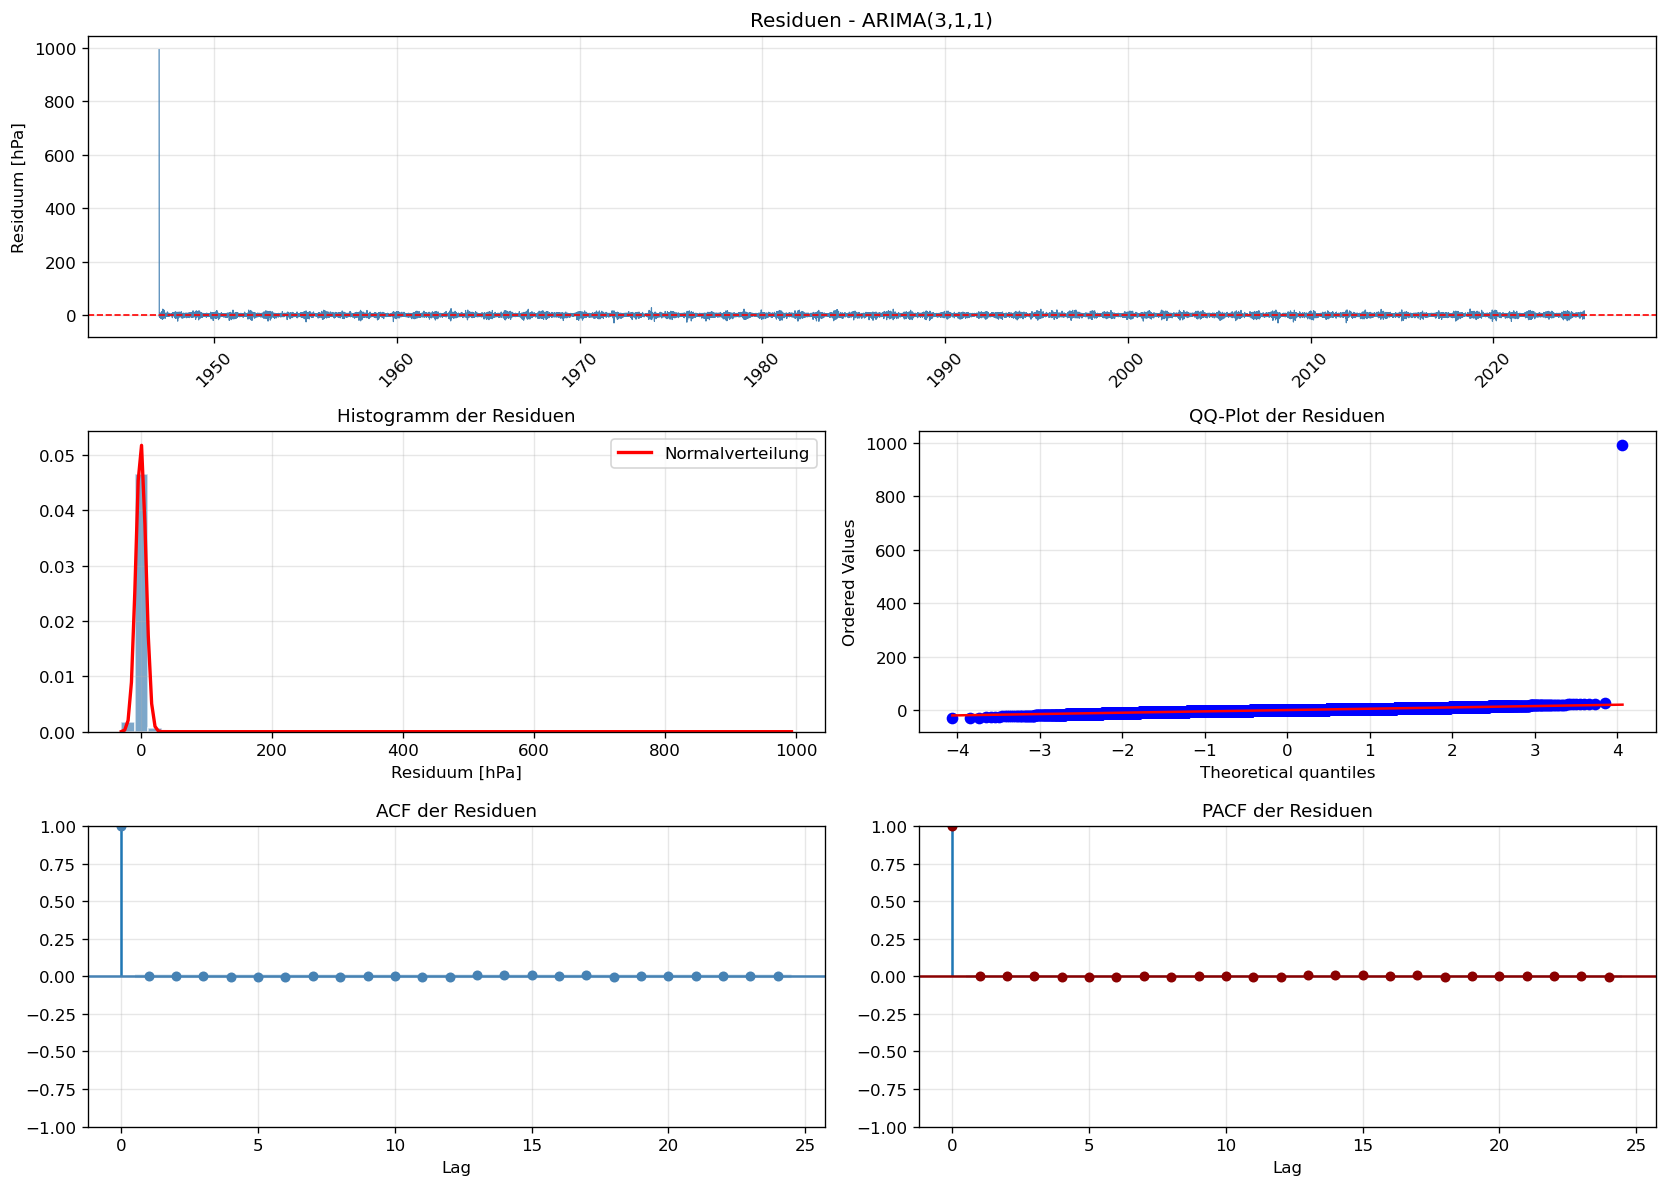


[Abbildung 4 gespeichert: 04_residuenanalyse.png]

  --- Statistische Tests auf Residuen ---

  Ljung-Box-Test (H0: keine Autokorrelation):
    Lag 10: Q=3.723, p=0.9590  => H0 nicht abgelehnt (ok)
    Lag 20: Q=12.755, p=0.8877  => H0 nicht abgelehnt (ok)
    Lag 30: Q=14.970, p=0.9899  => H0 nicht abgelehnt (ok)

  Jarque-Bera-Test (H0: Normalverteilung):
    Statistik=119763558865.397, p=0.0000  => H0 ABGELEHNT (!)

  ADF-Test auf Residuen (H0: Einheitswurzel):
    Statistik=-39.0063, p=0.0000  => Stationaer (ok)


In [12]:
print("\n" + "=" * 65)
print("SCHRITT 5: RESIDUENANALYSE UND MODELLDIAGNOSE")
print("=" * 65)

residuen = fit_final.resid

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig)

# Residuen ueber Zeit
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuen.index, residuen.values, lw=0.7, color="steelblue")
ax1.axhline(0, color="red", ls="--", lw=1)
ax1.set_title(f"Residuen - ARIMA({p_final},{d_final},{q_final})", fontsize=12)
ax1.set_ylabel("Residuum [hPa]")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator(10))
ax1.tick_params(axis="x", rotation=45)

# Histogramm der Residuen
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(
    residuen, bins=50, color="steelblue", edgecolor="white", density=True, alpha=0.7
)
x_norm = np.linspace(residuen.min(), residuen.max(), 200)
ax2.plot(
    x_norm,
    stats.norm.pdf(x_norm, residuen.mean(), residuen.std()),
    "r-", lw=2, label="Normalverteilung"
)
ax2.set_title("Histogramm der Residuen", fontsize=11)
ax2.set_xlabel("Residuum [hPa]")
ax2.legend()
ax2.grid(True, alpha=0.3)

# QQ-Plot
ax3 = fig.add_subplot(gs[1, 1])
stats.probplot(residuen, dist="norm", plot=ax3)
ax3.set_title("QQ-Plot der Residuen", fontsize=11)
ax3.grid(True, alpha=0.3)

# ACF der Residuen
ax4 = fig.add_subplot(gs[2, 0])
plot_acf(residuen, lags=24, ax=ax4, alpha=0.05, color="steelblue")
ax4.set_title("ACF der Residuen", fontsize=11)
ax4.set_xlabel("Lag")
ax4.grid(True, alpha=0.3)

# PACF der Residuen
ax5 = fig.add_subplot(gs[2, 1])
plot_pacf(residuen, lags=24, ax=ax5, alpha=0.05, color="darkred", method="ywm")
ax5.set_title("PACF der Residuen", fontsize=11)
ax5.set_xlabel("Lag")
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "04_residuenanalyse.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 4 gespeichert: 04_residuenanalyse.png]")

# Statistische Tests auf Residuen
print("\n  --- Statistische Tests auf Residuen ---")

# Ljung-Box-Test (keine Autokorrelation in Residuen)
lb_result = acorr_ljungbox(residuen, lags=[10, 20, 30], return_df=True)
print("\n  Ljung-Box-Test (H0: keine Autokorrelation):")
for lag in [10, 20, 30]:
    row = lb_result.loc[lag]
    entscheid = "nicht abgelehnt (ok)" if row["lb_pvalue"] > 0.05 else "ABGELEHNT (!)"
    print(
        f"    Lag {lag:2d}: Q={row['lb_stat']:.3f}, "
        f"p={row['lb_pvalue']:.4f}  => H0 {entscheid}"
    )

# Normalverteilungstest
jb_stat, jb_p = stats.jarque_bera(residuen)
jb_entscheid = "nicht abgelehnt (ok)" if jb_p > 0.05 else "ABGELEHNT (!)"
print(f"\n  Jarque-Bera-Test (H0: Normalverteilung):")
print(f"    Statistik={jb_stat:.3f}, p={jb_p:.4f}  => H0 {jb_entscheid}")

# ADF auf Residuen
print("\n  ADF-Test auf Residuen (H0: Einheitswurzel):")
adf_res = adfuller(residuen, autolag="AIC")
adf_entscheid = "Stationaer (ok)" if adf_res[1] < 0.05 else "Nicht stationaer (!)"
print(f"    Statistik={adf_res[0]:.4f}, p={adf_res[1]:.4f}  => {adf_entscheid}")

## 9. PROGNOSE (SCHRITT 7)


SCHRITT 7: PROGNOSE DER NAECHSTEN 10 TAGE

  10-Tage-Prognose ab 01.01.2025:

  Datum                  Prognose   95%-KI untere    95%-KI obere
  ---------------------------------------------------------------
  01.01.2025               993.45          983.92         1002.99
  02.01.2025               990.83          977.30         1004.35
  03.01.2025               989.13          974.12         1004.14
  04.01.2025               987.96          972.35         1003.57
  05.01.2025               987.10          971.19         1003.01
  06.01.2025               986.47          970.38         1002.55
  07.01.2025               986.00          969.82         1002.17
  08.01.2025               985.66          969.43         1001.89
  09.01.2025               985.41          969.15         1001.67
  10.01.2025               985.23          968.96         1001.51


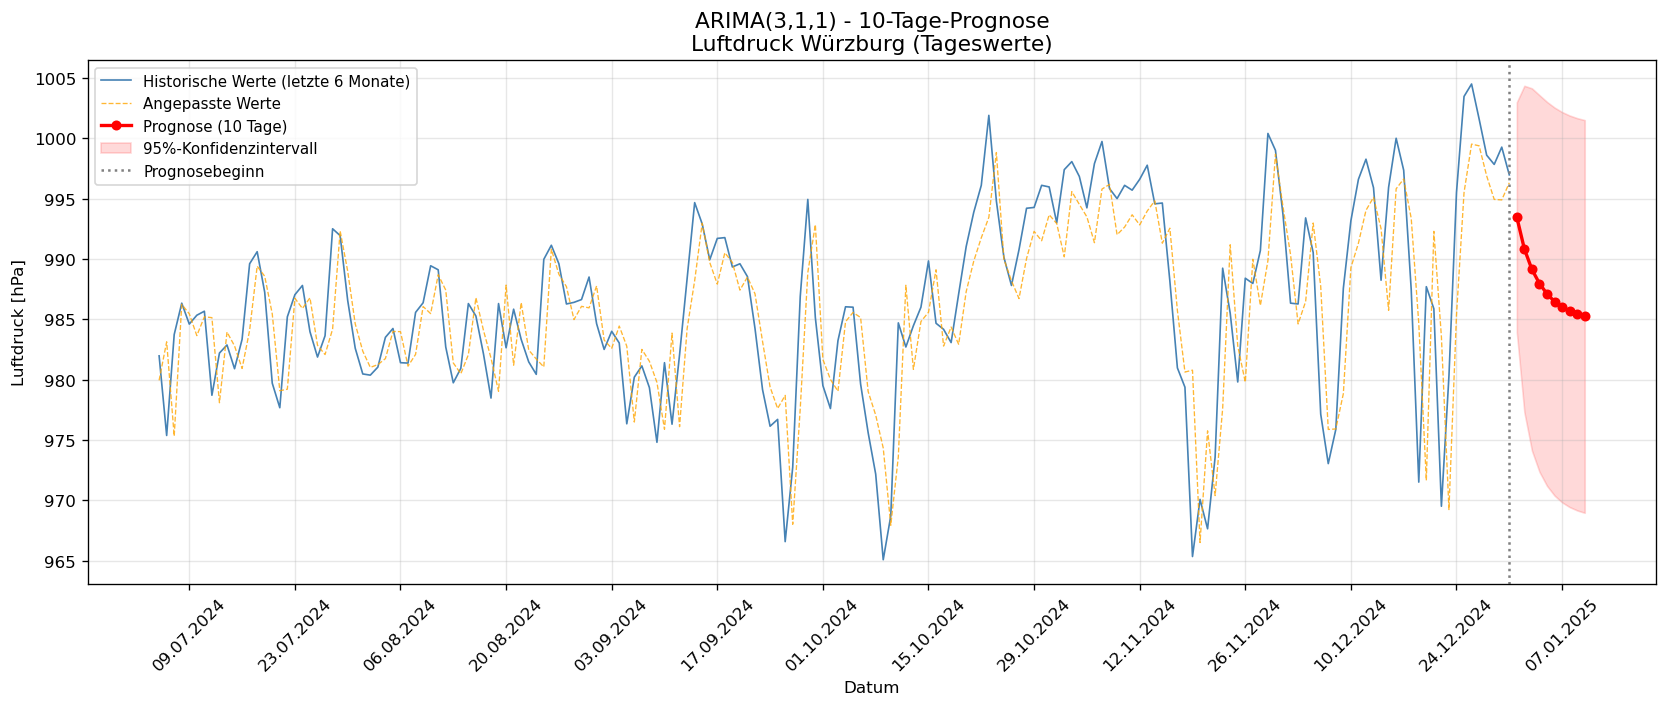


[Abbildung 5 gespeichert: 05_prognose.png]


In [13]:
print("\n" + "=" * 65)
print("SCHRITT 7: PROGNOSE DER NAECHSTEN 10 TAGE")
print("=" * 65)

n_prognose = 10
prognose = fit_final.get_forecast(steps=n_prognose)
prog_mittel = prognose.predicted_mean
prog_ki = prognose.conf_int(alpha=0.05)

# Prognosedaten ausgeben
print(f"\n  10-Tage-Prognose ab {prog_mittel.index[0].strftime('%d.%m.%Y')}:")
print(
    f"\n  {'Datum':<18} {'Prognose':>12} "
    f"{'95%-KI untere':>15} {'95%-KI obere':>15}"
)
print("  " + "-" * 63)
for datum, prog, ki_u, ki_o in zip(
    prog_mittel.index,
    prog_mittel.values,
    prog_ki.iloc[:, 0].values,
    prog_ki.iloc[:, 1].values,
):
    print(
        f"  {datum.strftime('%d.%m.%Y'):<18} {prog:>12.2f} "
        f"{ki_u:>15.2f} {ki_o:>15.2f}"
    )

# Visualisierung der Prognose
n_historisch = 180  # letzte 6 Monate fuer Plot
ts_plot = ts.iloc[-n_historisch:]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    ts_plot.index, ts_plot.values,
    color="steelblue", lw=1.0,
    label="Historische Werte (letzte 6 Monate)"
)

# Historische Fitted Values (letzter Abschnitt)
fitted = fit_final.fittedvalues.iloc[-n_historisch:]
ax.plot(
    fitted.index, fitted.values,
    color="orange", lw=0.8, ls="--", alpha=0.8,
    label="Angepasste Werte"
)

ax.plot(
    prog_mittel.index, prog_mittel.values,
    color="red", lw=2, marker="o", markersize=5,
    label="Prognose (10 Tage)"
)
ax.fill_between(
    prog_ki.index,
    prog_ki.iloc[:, 0],
    prog_ki.iloc[:, 1],
    color="red", alpha=0.15,
    label="95%-Konfidenzintervall"
)

ax.axvline(ts.index[-1], color="gray", ls=":", lw=1.5, label="Prognosebeginn")
ax.set_title(
    f"ARIMA({p_final},{d_final},{q_final}) - 10-Tage-Prognose\n"
    f"Luftdruck Würzburg (Tageswerte)",
    fontsize=13,
)
ax.set_ylabel("Luftdruck [hPa]")
ax.set_xlabel("Datum")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "05_prognose.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 5 gespeichert: 05_prognose.png]")

## ABSCHNITT 8: TRAIN/TEST-SPLIT (70/30) & MODELL-EVALUATION

In [ ]:
print("\n" + "=" * 65)
print("ABSCHNITT 8: MODELL-EVALUATION – TRAIN/TEST-SPLIT (70/30)")
print("=" * 65)

n_train   = int(len(ts) * 0.70)
ts_train  = ts.iloc[:n_train]
ts_test   = ts.iloc[n_train:]
print(f"\n  Trainingsdaten : {len(ts_train):,} Tage  "
      f"({ts_train.index[0].date()} – {ts_train.index[-1].date()})")
print(f"  Testdaten      : {len(ts_test):,} Tage  "
      f"({ts_test.index[0].date()} – {ts_test.index[-1].date()})")

print(f"\n  Schaetze ARIMA({p_final},{d_final},{q_final}) auf Trainingsdaten ...")
fit_train = ARIMA(ts_train, order=(p_final, d_final, q_final)).fit()
fc_obj    = fit_train.get_forecast(steps=len(ts_test))
fc_werte  = fc_obj.predicted_mean
fc_ki     = fc_obj.conf_int(alpha=0.05)
fc_werte.index = ts_test.index
fc_ki.index    = ts_test.index

mse_test  = mean_squared_error(ts_test, fc_werte)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(ts_test, fc_werte)
mape_test = np.mean(np.abs((ts_test.values - fc_werte.values) / ts_test.values)) * 100

print(f"\n  Test-Set-Metriken (Multi-Step-Prognose ueber {len(ts_test):,} Tage):")
print(f"  {'Metrik':<8}  {'Wert':>12}  Einheit")
print("  " + "-" * 36)
print(f"  {'MSE':<8}  {mse_test:>12.4f}  hPa^2")
print(f"  {'RMSE':<8}  {rmse_test:>12.4f}  hPa")
print(f"  {'MAE':<8}  {mae_test:>12.4f}  hPa")
print(f"  {'MAPE':<8}  {mape_test:>12.4f}  %")

# Plot: Train/Test-Split + Evaluation
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Abb. 6a: gesamter Split
axes[0].plot(ts_train.index, ts_train.values, color="steelblue", lw=0.5,
             label=f"Trainingsdaten ({len(ts_train):,} Tage, 70%)")
axes[0].plot(ts_test.index,  ts_test.values,  color="darkorange", lw=0.5,
             label=f"Testdaten ({len(ts_test):,} Tage, 30%)")
axes[0].axvline(ts_test.index[0], color="black", ls="--", lw=1.2,
                label=f"Split: {ts_test.index[0].date()}")
axes[0].set_title("Train/Test-Split (70/30) – Luftdruck Wuerzburg", fontsize=12)
axes[0].set_ylabel("Luftdruck [hPa]")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].xaxis.set_major_locator(mdates.YearLocator(10))
axes[0].tick_params(axis="x", rotation=45)

# Abb. 6b: Prognose vs. Ist auf Testdaten (letzte 3 Jahre des Tests)
n_zoom = min(1095, len(ts_test))
axes[1].plot(ts_test.iloc[-n_zoom:].index, ts_test.iloc[-n_zoom:].values,
             color="darkorange", lw=0.8, label="Ist-Werte (Test)")
axes[1].plot(fc_werte.iloc[-n_zoom:].index, fc_werte.iloc[-n_zoom:].values,
             color="red", lw=1.0, ls="--", label="Prognose (Multi-Step)")
axes[1].fill_between(fc_ki.iloc[-n_zoom:].index,
                     fc_ki.iloc[-n_zoom:, 0], fc_ki.iloc[-n_zoom:, 1],
                     color="red", alpha=0.10, label="95%-KI")
axes[1].set_title(
    f"Test-Evaluation – ARIMA({p_final},{d_final},{q_final})\n"
    f"MSE={mse_test:.2f}  RMSE={rmse_test:.2f}  MAE={mae_test:.2f}  MAPE={mape_test:.2f}%",
    fontsize=11
)
axes[1].set_ylabel("Luftdruck [hPa]")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "06_train_test_evaluation.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 6 gespeichert: 06_train_test_evaluation.png]")

## ABSCHNITT 9: TIME-SERIES-CROSS-VALIDATION (5-Fold)


ABSCHNITT 9: TIME-SERIES-CROSS-VALIDATION (5-Fold)

  CV-Pool    : letzte 730 Tage der Trainingsdaten
  Fold-Groesse: 30 Tage | Anzahl Folds: 5

  Fold    Train-Obs        MSE       RMSE        MAE    MAPE(%)
  ------------------------------------------------------------
  1             580    70.1189     8.3737     6.7942     0.6977
  2             610    39.1589     6.2577     5.3957     0.5509
  3             640    30.8537     5.5546     4.7421     0.4809
  4             670    33.0560     5.7494     4.5685     0.4625
  5             700    17.6663     4.2031     3.2923     0.3346
  ------------------------------------------------------------
  Mittel               38.1707     6.0277     4.9586     0.5053
  Std.                 19.5051     1.5155     1.2783     0.1329


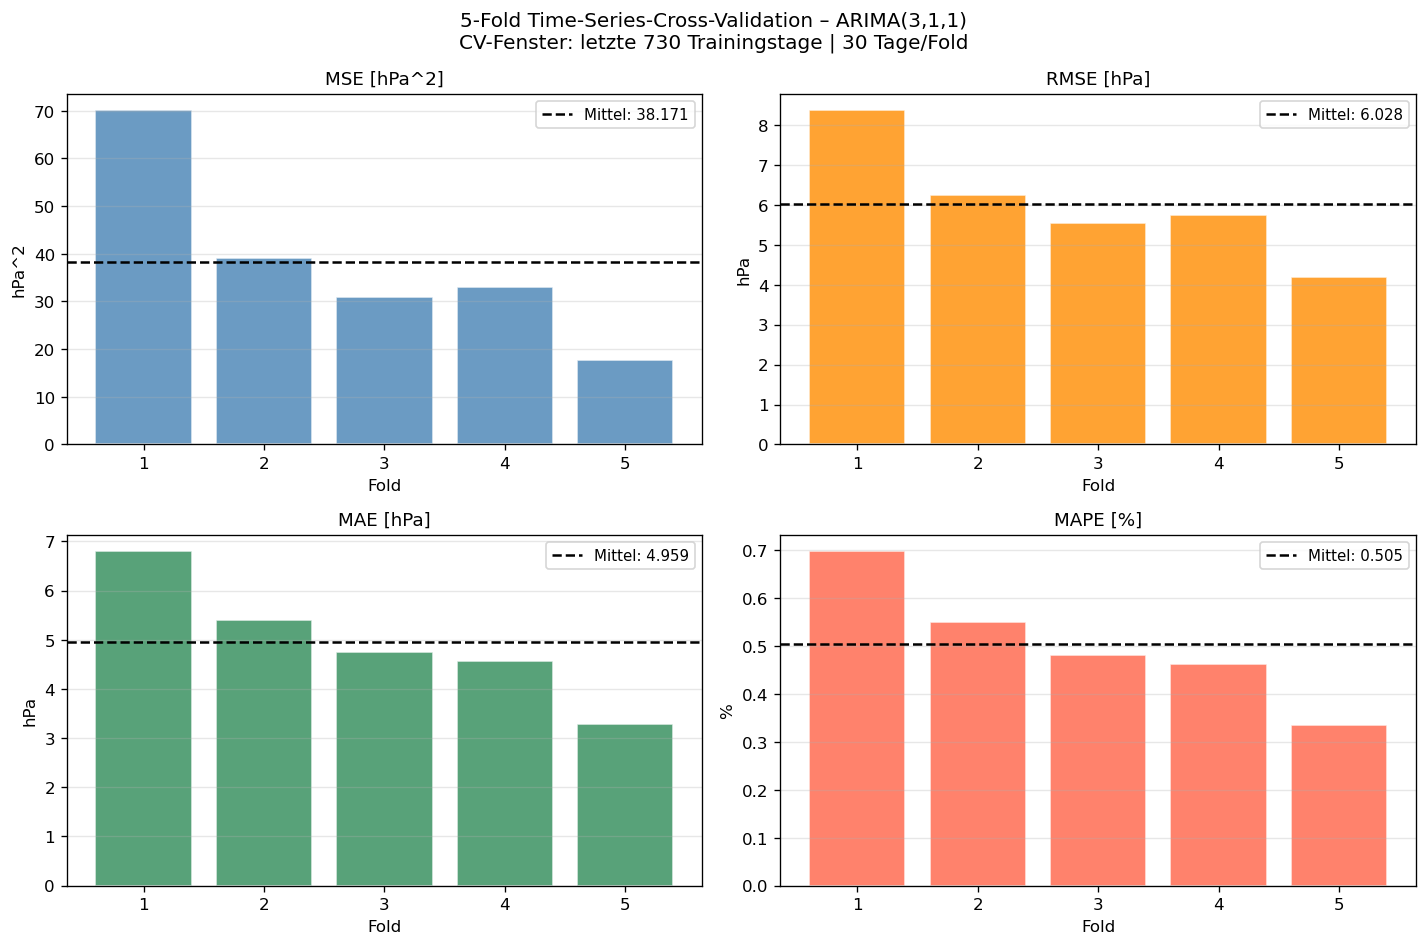


[Abbildung 7 gespeichert: 07_cv_metriken.png]


In [15]:
print("\n" + "=" * 65)
print("ABSCHNITT 9: TIME-SERIES-CROSS-VALIDATION (5-Fold)")
print("=" * 65)

CV_FENSTER  = 730
CV_TESTSIZE = 30
N_SPLITS    = 5
ts_cv = ts_train.iloc[-CV_FENSTER:]
tscv  = TimeSeriesSplit(n_splits=N_SPLITS, test_size=CV_TESTSIZE)

print(f"\n  CV-Pool    : letzte {CV_FENSTER} Tage der Trainingsdaten")
print(f"  Fold-Groesse: {CV_TESTSIZE} Tage | Anzahl Folds: {N_SPLITS}\n")
print(f"  {'Fold':<6} {'Train-Obs':>10} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'MAPE(%)':>10}")
print("  " + "-" * 60)

fold_metriken = []
for fold, (idx_tr, idx_te) in enumerate(tscv.split(ts_cv)):
    cv_tr = ts_cv.iloc[idx_tr]
    cv_te = ts_cv.iloc[idx_te]
    fc_cv = ARIMA(cv_tr, order=(p_final, d_final, q_final)).fit() \
                 .get_forecast(steps=len(cv_te)).predicted_mean
    fc_cv.index = cv_te.index
    m = {
        "Fold": fold + 1,
        "MSE" : mean_squared_error(cv_te, fc_cv),
        "RMSE": np.sqrt(mean_squared_error(cv_te, fc_cv)),
        "MAE" : mean_absolute_error(cv_te, fc_cv),
        "MAPE": np.mean(np.abs((cv_te.values - fc_cv.values) / cv_te.values)) * 100,
    }
    fold_metriken.append(m)
    print(f"  {m['Fold']:<6} {len(cv_tr):>10,} {m['MSE']:>10.4f} "
          f"{m['RMSE']:>10.4f} {m['MAE']:>10.4f} {m['MAPE']:>10.4f}")

cv_df = pd.DataFrame(fold_metriken)
print("  " + "-" * 60)
print(f"  {'Mittel':<17} {cv_df['MSE'].mean():>10.4f} {cv_df['RMSE'].mean():>10.4f} "
      f"{cv_df['MAE'].mean():>10.4f} {cv_df['MAPE'].mean():>10.4f}")
print(f"  {'Std.':<17} {cv_df['MSE'].std():>10.4f} {cv_df['RMSE'].std():>10.4f} "
      f"{cv_df['MAE'].std():>10.4f} {cv_df['MAPE'].std():>10.4f}")

# CV-Plot: Balkendiagramm der Fold-Metriken
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (metrik, farbe) in zip(
    axes.flat,
    [("MSE","steelblue"),("RMSE","darkorange"),("MAE","seagreen"),("MAPE","tomato")]
):
    werte = cv_df[metrik]
    ax.bar(werte.index + 1, werte.values, color=farbe, alpha=0.8, edgecolor="white")
    ax.axhline(werte.mean(), color="black", ls="--", lw=1.5,
               label=f"Mittel: {werte.mean():.3f}")
    einheit = "%" if metrik == "MAPE" else "hPa^2" if metrik == "MSE" else "hPa"
    ax.set_title(f"{metrik} [{einheit}]", fontsize=11)
    ax.set_xlabel("Fold")
    ax.set_ylabel(einheit)
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"5-Fold Time-Series-Cross-Validation – ARIMA({p_final},{d_final},{q_final})\n"
    f"CV-Fenster: letzte {CV_FENSTER} Trainingstage | {CV_TESTSIZE} Tage/Fold",
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, "07_cv_metriken.png"), bbox_inches="tight")
plt.show()
print("\n[Abbildung 7 gespeichert: 07_cv_metriken.png]")

## ZUSAMMENFASSUNG

In [17]:
print("\n" + "=" * 65)
print("ZUSAMMENFASSUNG")
print("=" * 65)
print(f"""
  Datensatz    : Luftdruck Wuerzburg, Station 5705
  Zeitraum     : {ts.index[0].strftime('%d.%m.%Y')} - {ts.index[-1].strftime('%d.%m.%Y')}
  Beobachtungen: {len(ts):,} Tageswerte

  Integrationsordnung : d = {d_final}
  Gewaaehltes Modell  : ARIMA({p_final},{d_final},{q_final})
  AIC                 : {fit_final.aic:.2f}
  BIC                 : {fit_final.bic:.2f}
  Log-Likelihood      : {fit_final.llf:.2f}

  --- Test-Set (30%, {len(ts_test):,} Tage) ---
  MSE   : {mse_test:.4f} hPa^2
  RMSE  : {rmse_test:.4f} hPa
  MAE   : {mae_test:.4f} hPa
  MAPE  : {mape_test:.4f} %

  --- Cross-Validation (5-Fold, Mittelwert) ---
  MSE   : {cv_df['MSE'].mean():.4f} hPa^2
  RMSE  : {cv_df['RMSE'].mean():.4f} hPa
  MAE   : {cv_df['MAE'].mean():.4f} hPa
  MAPE  : {cv_df['MAPE'].mean():.4f} %

  Prognose (10 Tage)  : {prog_mittel.values[0]:.2f} - {prog_mittel.values[-1]:.2f} hPa
  95%-KI (letzte Prog.): [{prog_ki.iloc[-1, 0]:.2f}, {prog_ki.iloc[-1, 1]:.2f}] hPa
""")
print("Alle Abbildungen wurden gespeichert.")
print("=" * 65)


ZUSAMMENFASSUNG

  Datensatz    : Luftdruck Wuerzburg, Station 5705
  Zeitraum     : 01.01.1947 - 31.12.2024
  Beobachtungen: 28,490 Tageswerte

  Integrationsordnung : d = 1
  Gewaaehltes Modell  : ARIMA(3,1,1)
  AIC                 : 170982.41
  BIC                 : 171023.70
  Log-Likelihood      : -85486.20

  --- Test-Set (30%, 8,547 Tage) ---
  MSE   : 72.4542 hPa^2
  RMSE  : 8.5120 hPa
  MAE   : 6.6563 hPa
  MAPE  : 0.6754 %

  --- Cross-Validation (5-Fold, Mittelwert) ---
  MSE   : 38.1707 hPa^2
  RMSE  : 6.0277 hPa
  MAE   : 4.9586 hPa
  MAPE  : 0.5053 %

  Prognose (10 Tage)  : 993.45 - 985.23 hPa
  95%-KI (letzte Prog.): [968.96, 1001.51] hPa

Alle Abbildungen wurden gespeichert.
